In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [12]:
# 1. Load the Data
df = pd.read_csv('france_accidents_2023_2024_cleaned.csv')

C:\Users\guscr\AppData\Local\Temp\ipykernel_27900\3282379490.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('france_accidents_2023_2024_cleaned.csv')


In [13]:
# 2. Select Features (Inputs) and Target (Output)
# We pick the columns that likely influence severity
features = [
    'lum',       # Lighting (Day/Night)
    'agg',       # Agglomeration (City/Highway)
    'int',       # Intersection Type
    'atm',       # Weather
    'col',       # Collision Type
    'catr',      # Road Category (Highway/local road)
    'hour',      # Hour of day
    'nb_vehicules' # Number of vehicles involved
]

target = 'target_severe'

In [14]:
# 3. Data Prep
# Drop rows with missing values in these specific columns
df_model = df.dropna(subset=features + [target]).copy()

# One-Hot Encoding: Convert categories
X = pd.get_dummies(df_model[features], columns=['lum', 'agg', 'int', 'atm', 'col', 'catr'])
y = df_model[target]

In [15]:
# 4. Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {len(X_train)} accidents...")
print(f"Testing on {len(X_test)} accidents...")

Training on 87371 accidents...
Testing on 21843 accidents...


In [16]:
# 5. Train the Model
# n_estimators=100 means we build 100 decision trees
# class_weight='balanced' is CRITICAL because severe accidents are rare. 
# It tells the model to pay more attention to the minority class (Severity=1).
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [17]:
# 6. Evaluation
y_pred = rf.predict(X_test)

In [18]:
# Print Scores
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     13955
           1       0.55      0.57      0.56      7888

    accuracy                           0.67     21843
   macro avg       0.65      0.65      0.65     21843
weighted avg       0.68      0.67      0.68     21843



<Figure size 600x600 with 0 Axes>

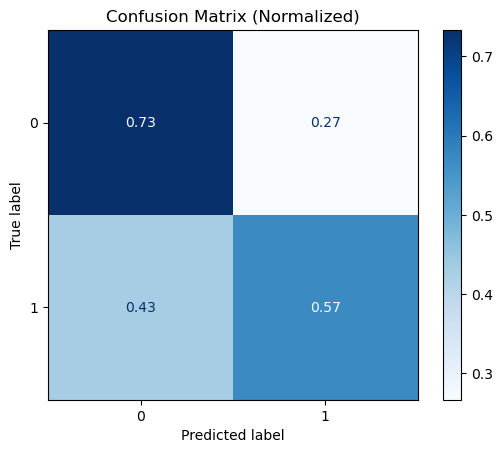

In [19]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', normalize='true')
plt.title('Confusion Matrix (Normalized)')
plt.show()

# Feature importance

C:\Users\guscr\AppData\Local\Temp\ipykernel_27900\3611374876.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature Name', data=feature_imp, palette='viridis')


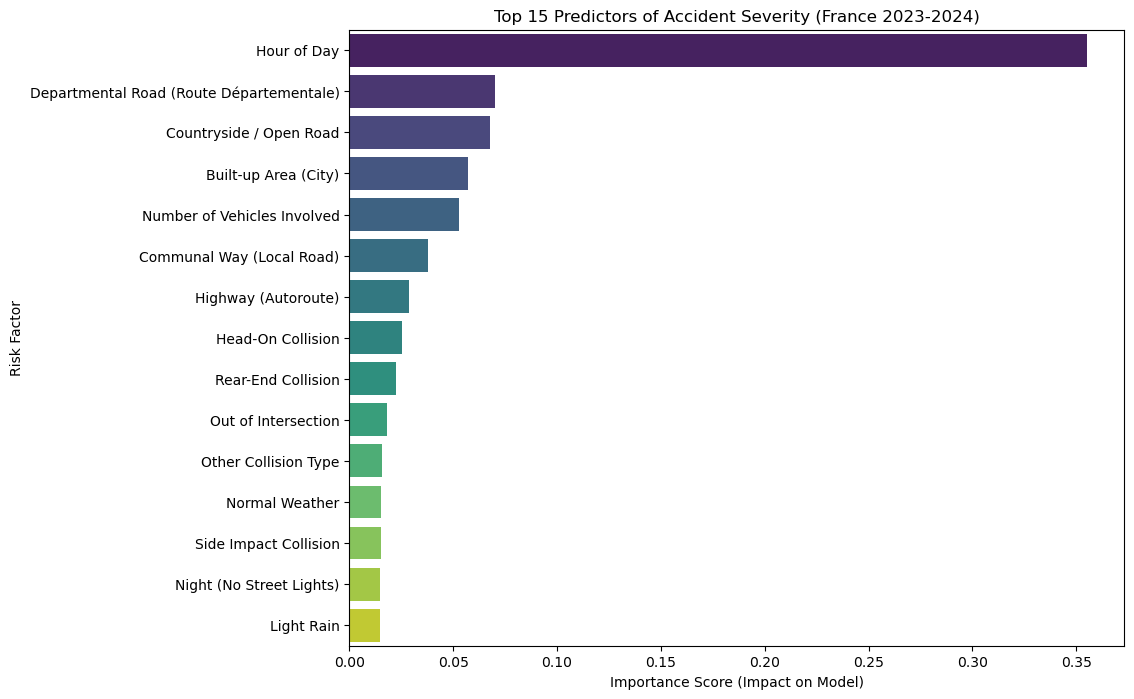

In [ ]:
importances = rf.feature_importances_
feature_names = X_test.columns
feature_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(15)

label_mapping = {
    'hour': 'Hour of Day',
    'catr_3': 'Departmental Road (Route Départementale)',
    'agg_1': 'Countryside / Open Road',
    'agg_2': 'Built-up Area (City)',
    'nb_vehicules': 'Number of Vehicles Involved',
    'catr_4': 'Communal Way (Local Road)',
    'catr_1': 'Highway (Autoroute)',
    'col_2': 'Head-On Collision',
    'col_1': 'Rear-End Collision',
    'int_1': 'Out of Intersection',
    'col_6': 'Other Collision Type',
    'atm_1': 'Normal Weather',
    'col_3': 'Side Impact Collision',
    'lum_3': 'Night (No Street Lights)',
    'atm_2': 'Light Rain'
}

feature_imp['Feature Name'] = feature_imp['Feature'].map(label_mapping).fillna(feature_imp['Feature'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature Name', data=feature_imp, palette='viridis')

plt.title('Top 15 Predictors of Accident Severity (France 2023-2024)')
plt.xlabel('Importance Score (Impact on Model)')
plt.ylabel('Risk Factor')
plt.show()

# Score Risk Zones

In [ ]:
all_probs = rf.predict_proba(X)[:, 1] 

df_model['AI_Risk_Score'] = all_probs

In [ ]:
df_model['lat_cluster'] = df_model['lat'].round(3)
df_model['long_cluster'] = df_model['long'].round(3)

In [ ]:
zone_scoring = df_model.groupby(['lat_cluster', 'long_cluster']).agg(
    Historical_Accidents=('target_severe', 'count'),
    Historical_Severe_Count=('target_severe', 'sum'),
    Real_Severity_Rate=('target_severe', 'mean'),
    AI_Predicted_Risk=('AI_Risk_Score', 'mean')
).reset_index()

In [ ]:
scored_zones = zone_scoring[zone_scoring['Historical_Accidents'] >= 5].copy()

In [ ]:
top_scored_zones = scored_zones.sort_values(by='AI_Predicted_Risk', ascending=False).head(10)

print("--- FINAL RISK SCORING (Top 10 Zones by AI Prediction) ---")
display(top_scored_zones)

correlation = scored_zones['Real_Severity_Rate'].corr(scored_zones['AI_Predicted_Risk'])
print(f"\nCorrelation between Model Risk Score and Real Severity: {round(correlation, 2)}")

--- FINAL RISK SCORING (Top 10 Zones by AI Prediction) ---


,lat_cluster,long_cluster,Historical_Accidents,Historical_Severe_Count,Real_Severity_Rate,AI_Predicted_Risk
75549,48.964,2.268,5,0,0.000000,0.822513
1855,-17.592,-149.391,10,9,0.900000,0.802748
1484,-20.896,55.495,5,4,0.800000,0.779063
1826,-17.722,-149.399,8,7,0.875000,0.715645
2049,-16.388,-151.765,10,9,0.900000,0.708423
1835,-17.696,-149.548,9,8,0.888889,0.672226
2016,-16.821,-151.404,5,5,1.000000,0.669715
1807,-17.756,-148.736,14,14,1.000000,0.665625
82127,49.447,5.919,5,0,0.000000,0.648384
1860,-17.577,-150.202,13,13,1.000000,0.636346



Correlation between Model Risk Score and Real Severity: 0.46


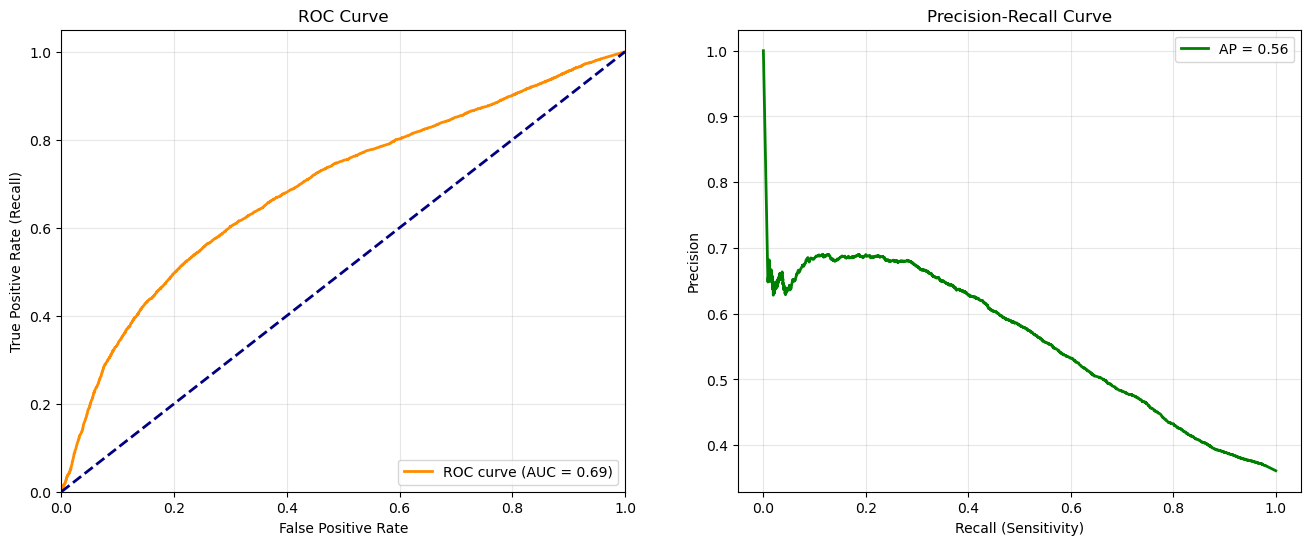

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_probs = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

# --- Plotting ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate (Recall)')
ax[0].set_title('ROC Curve')
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.3)

# Plot Precision-Recall
ax[1].plot(recall, precision, color='green', lw=2, label=f'AP = {avg_precision:.2f}')
ax[1].set_xlabel('Recall (Sensitivity)')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="upper right")
ax[1].grid(True, alpha=0.3)

plt.show()

--- Classification Report (Threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.78      0.52      0.63     13955
           1       0.47      0.74      0.57      7888

    accuracy                           0.60     21843
   macro avg       0.62      0.63      0.60     21843
weighted avg       0.67      0.60      0.61     21843



<Figure size 600x600 with 0 Axes>

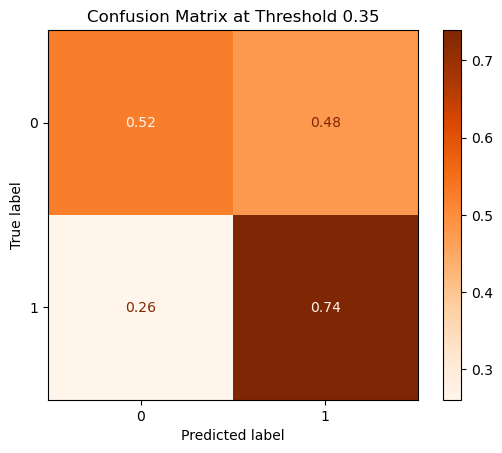

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_probs = rf.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred_low_thresh = (y_probs >= threshold).astype(int)

print(f"--- Classification Report (Threshold = {threshold}) ---")
print(classification_report(y_test, y_pred_low_thresh))

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_low_thresh, cmap='Oranges', normalize='true')
plt.title(f'Confusion Matrix at Threshold {threshold}')
plt.show()